<a href="https://colab.research.google.com/github/rajeshtikaddar/Internship/blob/main/CyberSecurity_Data_Prepossing_%24_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CyberSecurity Data Prepossing $ Feature Engineering**

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



**Load Dataset**

In [ ]:
df = pd.read_csv("/content/cybersecurity_login_data_120_records.csv")
df.head(10)

,User,Failed_Logins,Country,Device_Type,Login_Time,Account_Age_Days,Suspicious_Activity
0,Sneha1,30.0,Russia,Laptop,01:47,45,Yes
1,Ayesha2,60.0,Russia,Laptop,00:13,33,Yes
2,Manish3,250.0,Russia,Mobile,05:44,176,Yes
3,Riya4,120.0,Unknown,Laptop,02:55,217,Yes
4,Neha5,5.0,USA,Desktop,10:48,420,No
5,Sneha6,NaN,Russia,Mobile,02:22,226,Yes
6,Vikash7,120.0,Unknown,Laptop,00:24,246,Yes
7,Ayesha8,5.0,Unknown,Mobile,19:02,271,No
8,Pooja9,1.0,Unknown,Desktop,21:24,303,No
9,Sourav10,2.0,Germany,Desktop,13:42,414,No


**Dataset Exploration**

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User                 123 non-null    object 
 1   Failed_Logins        121 non-null    float64
 2   Country              123 non-null    object 
 3   Device_Type          123 non-null    object 
 4   Login_Time           123 non-null    object 
 5   Account_Age_Days     123 non-null    int64  
 6   Suspicious_Activity  123 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 6.9+ KB


,Failed_Logins,Account_Age_Days
count,121.000000,123.000000
mean,51.363636,361.967480
std,78.183651,345.948232
min,0.000000,21.000000
25%,5.000000,120.500000
50%,18.000000,203.000000
75%,45.000000,519.000000
max,250.000000,1183.000000


**Mising Values Analysis**

In [ ]:
df.isnull().sum()

,0
User,0
Failed_Logins,2
Country,0
Device_Type,0
Login_Time,0
Account_Age_Days,0
Suspicious_Activity,0


In [ ]:
df["Failed_Logins"] = df["Failed_Logins"].fillna(
    df["Failed_Logins"].median()
    )

In [ ]:
df.head(10)

,User,Failed_Logins,Country,Device_Type,Login_Time,Account_Age_Days,Suspicious_Activity
0,Sneha1,30.0,Russia,Laptop,01:47,45,Yes
1,Ayesha2,60.0,Russia,Laptop,00:13,33,Yes
2,Manish3,250.0,Russia,Mobile,05:44,176,Yes
3,Riya4,120.0,Unknown,Laptop,02:55,217,Yes
4,Neha5,5.0,USA,Desktop,10:48,420,No
5,Sneha6,18.0,Russia,Mobile,02:22,226,Yes
6,Vikash7,120.0,Unknown,Laptop,00:24,246,Yes
7,Ayesha8,5.0,Unknown,Mobile,19:02,271,No
8,Pooja9,1.0,Unknown,Desktop,21:24,303,No
9,Sourav10,2.0,Germany,Desktop,13:42,414,No


**Duplicate Records detection**

In [ ]:
df.duplicated().sum()

np.int64(3)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User                 120 non-null    object 
 1   Failed_Logins        120 non-null    float64
 2   Country              120 non-null    object 
 3   Device_Type          120 non-null    object 
 4   Login_Time           120 non-null    object 
 5   Account_Age_Days     120 non-null    int64  
 6   Suspicious_Activity  120 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 7.5+ KB


,Failed_Logins,Account_Age_Days
count,120.000000,120.00000
mean,47.900000,364.80000
std,74.080175,348.39458
min,0.000000,21.00000
25%,5.000000,120.75000
50%,18.000000,204.50000
75%,45.000000,530.75000
max,250.000000,1183.00000


**Outliers Detection**

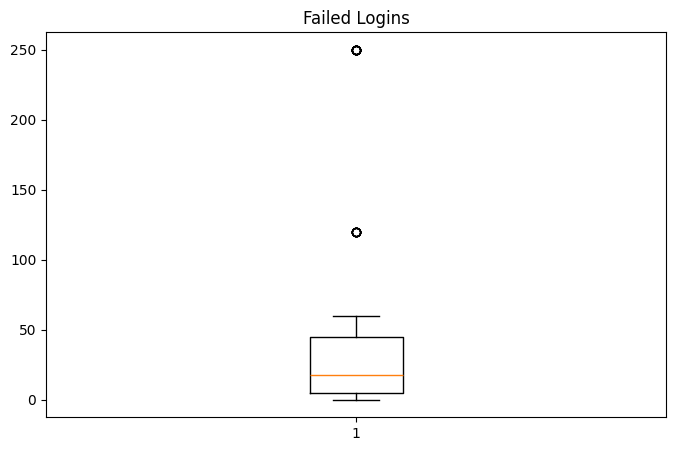

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Failed_Logins"])
plt.title("Failed Logins")
plt.show()

**Feature Engineering **

In [ ]:
high_risk = ["Russia","China","Unknown"]
df["High_Risk_Country"] = df["Country"].apply(
  lambda x: 1 if x in high_risk else 0
)

In [ ]:
df.head(10)

,User,Failed_Logins,Country,Device_Type,Login_Time,Account_Age_Days,Suspicious_Activity,High_Risk_Country
0,Sneha1,30.0,Russia,Laptop,01:47,45,Yes,1
1,Ayesha2,60.0,Russia,Laptop,00:13,33,Yes,1
2,Manish3,250.0,Russia,Mobile,05:44,176,Yes,1
3,Riya4,120.0,Unknown,Laptop,02:55,217,Yes,1
4,Neha5,5.0,USA,Desktop,10:48,420,No,0
5,Sneha6,18.0,Russia,Mobile,02:22,226,Yes,1
6,Vikash7,120.0,Unknown,Laptop,00:24,246,Yes,1
7,Ayesha8,5.0,Unknown,Mobile,19:02,271,No,1
8,Pooja9,1.0,Unknown,Desktop,21:24,303,No,1
9,Sourav10,2.0,Germany,Desktop,13:42,414,No,0


**Create Night Login Feature **

In [ ]:
df["Hour"] = pd.to_datetime(
    df["Login_Time"],
    errors="coerce"
).dt.hour

df["Night_Login"] = (df["Hour"] < 6 ).astype(int)

df[["Login_Time","Hour"]].head(10)

/tmp/ipykernel_3438/2988889548.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(


,Login_Time,Hour
0,01:47,1
1,00:13,0
2,05:44,5
3,02:55,2
4,10:48,10
5,02:22,2
6,00:24,0
7,19:02,19
8,21:24,21
9,13:42,13


In [ ]:
df.head(10)

,User,Failed_Logins,Country,Device_Type,Login_Time,Account_Age_Days,Suspicious_Activity,High_Risk_Country,Hour,Night_Login
0,Sneha1,30.0,Russia,Laptop,01:47,45,Yes,1,1,1
1,Ayesha2,60.0,Russia,Laptop,00:13,33,Yes,1,0,1
2,Manish3,250.0,Russia,Mobile,05:44,176,Yes,1,5,1
3,Riya4,120.0,Unknown,Laptop,02:55,217,Yes,1,2,1
4,Neha5,5.0,USA,Desktop,10:48,420,No,0,10,0
5,Sneha6,18.0,Russia,Mobile,02:22,226,Yes,1,2,1
6,Vikash7,120.0,Unknown,Laptop,00:24,246,Yes,1,0,1
7,Ayesha8,5.0,Unknown,Mobile,19:02,271,No,1,19,0
8,Pooja9,1.0,Unknown,Desktop,21:24,303,No,1,21,0
9,Sourav10,2.0,Germany,Desktop,13:42,414,No,0,13,0


**Create Login Risk Score **

In [ ]:
df["Login_Risk_Score"] = (
    df["Failed_Logins"]*0.6 +
    df["High_Risk_Country"]*20 +
    df["Night_Login"]*10
)

In [ ]:
df.head(10)

,User,Failed_Logins,Country,Device_Type,Login_Time,Account_Age_Days,Suspicious_Activity,High_Risk_Country,Hour,Night_Login,Login_Risk_Score
0,Sneha1,30.0,Russia,Laptop,01:47,45,Yes,1,1,1,48.0
1,Ayesha2,60.0,Russia,Laptop,00:13,33,Yes,1,0,1,66.0
2,Manish3,250.0,Russia,Mobile,05:44,176,Yes,1,5,1,180.0
3,Riya4,120.0,Unknown,Laptop,02:55,217,Yes,1,2,1,102.0
4,Neha5,5.0,USA,Desktop,10:48,420,No,0,10,0,3.0
5,Sneha6,18.0,Russia,Mobile,02:22,226,Yes,1,2,1,40.8
6,Vikash7,120.0,Unknown,Laptop,00:24,246,Yes,1,0,1,102.0
7,Ayesha8,5.0,Unknown,Mobile,19:02,271,No,1,19,0,23.0
8,Pooja9,1.0,Unknown,Desktop,21:24,303,No,1,21,0,20.6
9,Sourav10,2.0,Germany,Desktop,13:42,414,No,0,13,0,1.2


**Encoding Categorial Features **

In [ ]:
from sklearn.preprocessing import LabelEncoder

le =  LabelEncoder()

df["Device_Type"] = le.fit_transform(
    df["Device_Type"]
)

df["Suspicious_Activity"] = le.fit_transform(
    df["Suspicious_Activity"]
)


In [ ]:
df.head(10)

,User,Failed_Logins,Country,Device_Type,Login_Time,Account_Age_Days,Suspicious_Activity,High_Risk_Country,Hour,Night_Login,Login_Risk_Score
0,Sneha1,30.0,Russia,1,01:47,45,1,1,1,1,48.0
1,Ayesha2,60.0,Russia,1,00:13,33,1,1,0,1,66.0
2,Manish3,250.0,Russia,2,05:44,176,1,1,5,1,180.0
3,Riya4,120.0,Unknown,1,02:55,217,1,1,2,1,102.0
4,Neha5,5.0,USA,0,10:48,420,0,0,10,0,3.0
5,Sneha6,18.0,Russia,2,02:22,226,1,1,2,1,40.8
6,Vikash7,120.0,Unknown,1,00:24,246,1,1,0,1,102.0
7,Ayesha8,5.0,Unknown,2,19:02,271,0,1,19,0,23.0
8,Pooja9,1.0,Unknown,0,21:24,303,0,1,21,0,20.6
9,Sourav10,2.0,Germany,0,13:42,414,0,0,13,0,1.2


**Feature Selections And Final Dataset **

In [ ]:
final_dataset = df[
    [
    "Failed_Logins",
    "Device_Type",
    "Account_Age_Days",
    "High_Risk_Country",
    "Night_Login",
    "Login_Risk_Score",
    "Suspicious_Activity"
    ]
]

final_dataset.head(10)

,Failed_Logins,Device_Type,Account_Age_Days,High_Risk_Country,Night_Login,Login_Risk_Score,Suspicious_Activity
0,30.0,1,45,1,1,48.0,1
1,60.0,1,33,1,1,66.0,1
2,250.0,2,176,1,1,180.0,1
3,120.0,1,217,1,1,102.0,1
4,5.0,0,420,0,0,3.0,0
5,18.0,2,226,1,1,40.8,1
6,120.0,1,246,1,1,102.0,1
7,5.0,2,271,1,0,23.0,0
8,1.0,0,303,1,0,20.6,0
9,2.0,0,414,0,0,1.2,0


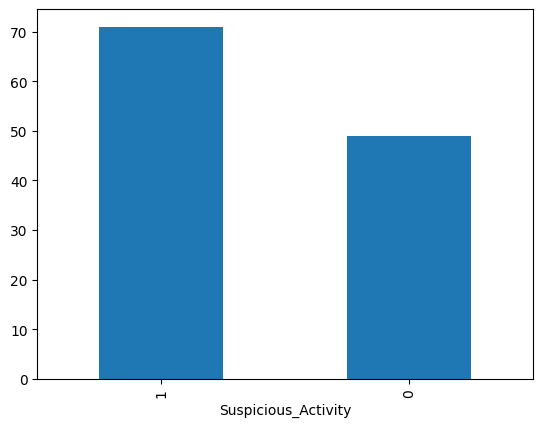

In [ ]:
final_dataset["Suspicious_Activity"].value_counts().plot(kind="bar")
plt.show()

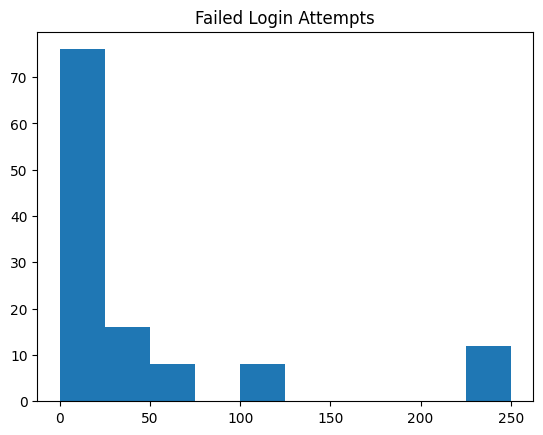

In [ ]:
plt.hist(final_dataset["Failed_Logins"])

plt.title("Failed Login Attempts")
plt.show()